In [35]:
# pandas and numpy
import pandas as pd
import numpy as np

# plot
import matplotlib.pyplot as plt, seaborn as sns

from sklearn import svm

#score

from sklearn.metrics import r2_score, median_absolute_error, mean_absolute_error
from sklearn.metrics import median_absolute_error, mean_squared_error, mean_squared_log_error




from itertools import cycle

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from scipy import interp
from sklearn.metrics import roc_auc_score

In [36]:
#read file

df = pd.read_csv("machine_ID_2.csv")

del df["Unnamed: 0"]

In [89]:
#saving dataframe on a different name

ds = df

#ds =df.drop(['datetime'], axis=1)
ds =ds.drop(['time_diff'], axis=1)
#ds =ds.drop(['model'], axis=1)
#ds =ds.drop(['age'], axis=1)
#ds =ds.drop(['machineID'], axis=1)
ds =ds.drop(['error1count'], axis=1)
ds =ds.drop(['error2count'], axis=1)
ds =ds.drop(['error3count'], axis=1)
ds =ds.drop(['error4count'], axis=1)
ds =ds.drop(['error5count'], axis=1)
ds =ds.drop(['failure'], axis=1)


ds =ds.drop(['voltmean'], axis=1)
ds =ds.drop(['rotatemean'], axis=1)
ds =ds.drop(['pressuremean'], axis=1)
ds =ds.drop(['vibrationmean'], axis=1)
ds =ds.drop(['voltsd'], axis=1)
ds =ds.drop(['rotatesd'], axis=1)
ds =ds.drop(['pressuresd'], axis=1)
ds =ds.drop(['vibrationsd'], axis=1)


ds

,datetime,machineID,model,age
0,2015-01-02T05:00:00Z,2.0,model4,7.0
1,2015-01-02T08:00:00Z,2.0,model4,7.0
2,2015-01-02T11:00:00Z,2.0,model4,7.0
3,2015-01-02T14:00:00Z,2.0,model4,7.0
4,2015-01-02T17:00:00Z,2.0,model4,7.0
...,...,...,...,...
2908,2015-12-31T17:00:00Z,2.0,model4,7.0
2909,2015-12-31T20:00:00Z,2.0,model4,7.0
2910,2015-12-31T23:00:00Z,2.0,model4,7.0
2911,2016-01-01T02:00:00Z,2.0,model4,7.0


In [38]:
def weighted_average(series, weights):
    """
        Calculate weighted average on series
    """
    for n in range(len(series)): 
        result = 0.0
        weights.reverse()
        for n in range(len(weights)):
            result += series.iloc[-n-1] * weights[n]
            series.iloc[-n] = result
        #return float(result)
    return series 
    

In [39]:
wei_avg = pd.DataFrame()
wei_avg['wei_voltmean'] = weighted_average(ds['voltmean'], [0.8,-0.07,-0.05,-0.03])
wei_avg['failure'] = df['failure']

In [40]:
#wei_voltmean.describe()


In [41]:
#wei_avg.query("wei_voltmean<160")

In [42]:
wei_avg['wei_rotatemean'] = weighted_average(ds['rotatemean'], [0.87,-0.07,-0.05,-0.03])


In [43]:
wei_avg['wei_pressuremean'] = weighted_average(ds['pressuremean'], [0.85,-0.17,-0.05,-0.03])


In [44]:
wei_avg['wei_vibrationmean'] = weighted_average(ds['vibrationmean'], [0.82,-0.07,-0.12,-0.03])


In [45]:
wei_avg['wei_voltsd'] = weighted_average(ds['voltsd'], [0.7,-0.05,-0.05,-0.03])


In [46]:
wei_avg['wei_rotatesd'] = weighted_average(ds['rotatesd'], [0.9,-0.07,-0.05,-0.05])


In [47]:
wei_avg['wei_vibrationsd'] = weighted_average(ds['vibrationsd'], [0.8,-0.5,-0.05,-0.03])


In [48]:
wei_avg['wei_pressuresd'] = weighted_average(ds['pressuresd'], [0.9,-0.07,-0.05,-0.05])


In [49]:
wei_avg.tail(5)

,wei_voltmean,failure,wei_rotatemean,wei_pressuremean,wei_vibrationmean,wei_voltsd,wei_rotatesd,wei_vibrationsd,wei_pressuresd
2908,166.569083,False,458.292778,100.631192,40.234731,14.144781,46.359921,5.702438,10.638965
2909,166.899065,False,454.400463,101.066046,40.221803,14.348292,44.121765,5.360968,10.671764
2910,146.398150,False,398.584539,88.651677,35.281190,12.585831,38.702102,4.702458,9.360906
2911,1.195963,False,3.256136,0.724218,0.288221,0.102817,0.316167,0.038416,0.076472
2912,0.348441,False,0.948668,0.210999,0.083973,0.029955,0.092115,0.011192,0.022280


In [50]:
wei_avg = wei_avg.drop(index = 0)
wei_avg = wei_avg.drop(index = 2911)
wei_avg = wei_avg.drop(index = 2912)


In [51]:
wei_avg.tail(5)

,wei_voltmean,failure,wei_rotatemean,wei_pressuremean,wei_vibrationmean,wei_voltsd,wei_rotatesd,wei_vibrationsd,wei_pressuresd
2906,168.569131,False,455.106349,101.053880,38.782146,14.365550,50.712992,5.473602,10.849184
2907,167.717768,False,451.457061,102.737289,39.623704,13.987749,51.699255,5.922676,11.985588
2908,166.569083,False,458.292778,100.631192,40.234731,14.144781,46.359921,5.702438,10.638965
2909,166.899065,False,454.400463,101.066046,40.221803,14.348292,44.121765,5.360968,10.671764
2910,146.398150,False,398.584539,88.651677,35.281190,12.585831,38.702102,4.702458,9.360906


In [52]:
'''
plt.figure(figsize=(15, 7))
plt.plot(wei_avg.values, "c", label = "Actual")
plt.legend(loc="best")
plt.axis('tight')
plt.title("Weighted Average")
plt.grid(True);
'''

'\nplt.figure(figsize=(15, 7))\nplt.plot(wei_avg.values, "c", label = "Actual")\nplt.legend(loc="best")\nplt.axis(\'tight\')\nplt.title("Weighted Average")\nplt.grid(True);\n'

In [53]:
wei_avg.to_csv('wei_avg_m2.csv') # save file


In [54]:
from sklearn.model_selection import train_test_split

y = wei_avg.failure
X = wei_avg.drop('failure', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2)


In [55]:
#Create a svm Classifier
clf = svm.SVC(kernel='linear') # Linear Kernel

#Train the model using the training sets
clf.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

In [56]:
from sklearn import metrics

print("Accuracy:",metrics.accuracy_score(y_test, y_pred))


Accuracy: 0.9965635738831615


In [57]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test,y_pred))


[[578   0]
 [  2   2]]


In [58]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       578
        True       1.00      0.50      0.67         4

    accuracy                           1.00       582
   macro avg       1.00      0.75      0.83       582
weighted avg       1.00      1.00      1.00       582



In [59]:
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[578,   0],
       [  2,   2]], dtype=int64)

Text(0.5, 257.44, 'Predicted label')

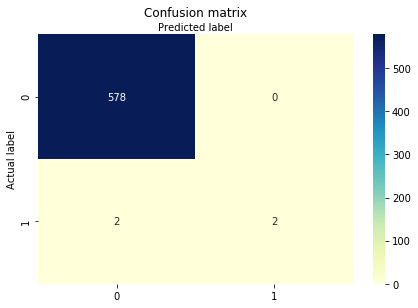

In [60]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

No Skill: ROC AUC=0.500
Logistic: ROC AUC=0.750


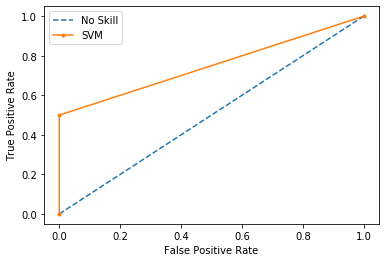

In [73]:
ns_probs = [0 for _ in range(len(y_test))]
lr_probs = y_pred

ns_auc = roc_auc_score(y_test, ns_probs)
lr_auc = roc_auc_score(y_test, lr_probs)
# summarize scores
print('No Skill: ROC AUC=%.3f' % (ns_auc))
print('SVM: ROC AUC=%.3f' % (lr_auc))
# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
# plot the roc curve for the model
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
plt.plot(lr_fpr, lr_tpr, marker='.', label='SVM')
# axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
# show the plot
plt.show()